# Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (path / "notebooks").is_dir() and (path / "data").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the repository root or notebooks directory.")

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "messy_edu_growth_99_columns.csv"
CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "edu_growth_cleaned.csv"


In [2]:
df=pd.read_csv(RAW_DATA_PATH,        
                 keep_default_na=False,na_values=[""])


In [3]:
df.shape


(49000, 99)

In [4]:
df.head()


,roll_no,full_name,class_section,overall_attendance_pct,theory_attendance_pct,practical_attendance_pct,previous_cgpa,medical_leave_days,society_participation_pc,sports_activity_level,...,lab_ds_submission_delay_hours,lab_python_execution_score,lab_python_viva_score,lab_python_submission_delay_hours,lab_coa_execution_score,lab_coa_viva_score,lab_coa_submission_delay_hours,lab_cyber_execution_score,lab_cyber_viva_score,lab_cyber_submission_delay_hours
0,210029053348,Aarav Shah,CS-DS,38.0,42.5,35.9,6.47,3.0,71.5,high,...,18.6,24.1,12.8,20.3,26.3,17.4,91.3,22.6,NaN,31.2
1,210029035828,Kabir Verma,CS-DS,70.3,68.1,77.9,8.30,0.0,22.7,MODERATE,...,36.4,38.4,19.5,13.4,32.4,26.2,14.9,31.9,17.3,NaN
2,210029039616,isha kumar,IT-A,53.6%,49.6,59.6,NaN,3.0,26.9,N/A,...,14.0,37.5,22.7,17.8,38.7,21.7,19.7,33.6,22.9,8.5
3,210029036528,Kabir Bhat,CS-DS,91.1,88.0,93.6,9.73,3.0,41.3,HIGH,...,21.4,42.2,25.2,10.5,47.7,27.0,16.0,50.0,27.9,5.7
4,210029010644,Aditya Das,CSE-A,76.4,67.1,75.3,7.97,2.0,9.2,LOW,...,13.0,42.2,22.4,10.3,36.1,24.0,17.2,42.6,26.3,25.0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 49000 entries, 0 to 48999
Data columns (total 99 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   roll_no                            49000 non-null  int64  
 1   full_name                          46573 non-null  str    
 2   class_section                      46633 non-null  str    
 3   overall_attendance_pct             46547 non-null  str    
 4   theory_attendance_pct              46529 non-null  float64
 5   practical_attendance_pct           46586 non-null  float64
 6   previous_cgpa                      46541 non-null  float64
 7   medical_leave_days                 46451 non-null  float64
 8   society_participation_pc           46626 non-null  float64
 9   sports_activity_level              46640 non-null  str    
 10  final_semester_grade               46702 non-null  float64
 11  coa_attendance_pct                 46508 non-null  float64
 12  m

In [6]:
df.describe()


,roll_no,theory_attendance_pct,practical_attendance_pct,previous_cgpa,medical_leave_days,society_participation_pc,final_semester_grade,coa_attendance_pct,maths4_attendance_pct,dstl_attendance_pct,...,lab_ds_submission_delay_hours,lab_python_execution_score,lab_python_viva_score,lab_python_submission_delay_hours,lab_coa_execution_score,lab_coa_viva_score,lab_coa_submission_delay_hours,lab_cyber_execution_score,lab_cyber_viva_score,lab_cyber_submission_delay_hours
count,4.900000e+04,46529.000000,46586.000000,46541.000000,46451.000000,46626.000000,46702.000000,46508.000000,46548.000000,46634.000000,...,46503.000000,46570.000000,46538.000000,46586.000000,46648.000000,46563.000000,46410.000000,46538.000000,46517.000000,46576.000000
mean,2.100290e+11,70.825661,72.695346,8.000971,2.014187,19.991091,7.848317,70.721738,70.700129,70.661224,...,20.289553,35.525162,21.299673,20.278910,35.468938,21.286174,20.329757,35.467932,21.231311,20.248366
std,1.341106e+04,18.900641,18.893053,1.244338,1.424162,19.444605,1.252405,19.265078,19.314908,19.285136,...,11.527010,9.455783,5.711696,11.463472,9.417669,5.711620,11.554847,9.433050,5.715019,11.467984
min,2.100290e+11,0.300000,0.500000,2.860000,0.000000,0.000000,2.870000,0.000000,0.000000,0.000000,...,0.300000,0.000000,0.000000,0.400000,0.000000,0.000000,0.500000,0.000000,0.000000,0.100000
25%,2.100290e+11,58.200000,60.100000,7.200000,1.000000,5.800000,7.040000,57.975000,57.800000,57.900000,...,12.200000,29.300000,17.500000,12.100000,29.300000,17.500000,12.200000,29.200000,17.400000,12.100000
50%,2.100290e+11,72.600000,74.500000,8.110000,2.000000,14.000000,7.990000,72.500000,72.500000,72.400000,...,18.100000,36.500000,21.800000,18.100000,36.400000,21.800000,18.100000,36.300000,21.800000,18.100000
75%,2.100290e+11,85.600000,87.700000,8.910000,3.000000,27.900000,8.800000,85.700000,85.900000,85.800000,...,25.900000,42.800000,25.700000,25.900000,42.600000,25.700000,25.900000,42.700000,25.600000,25.900000
max,2.100291e+11,100.000000,100.000000,15.500000,11.000000,100.000000,10.000000,100.000000,100.000000,100.000000,...,120.000000,50.000000,30.000000,120.000000,50.000000,30.000000,120.000000,50.000000,30.000000,120.000000


In [7]:
df.select_dtypes(include="object").nunique()


/tmp/ipykernel_42933/1007425721.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


full_name                  450
class_section                9
overall_attendance_pct    1669
sports_activity_level        8
dtype: int64

In [8]:
df.dtypes.value_counts()


float64    94
str         4
int64       1
Name: count, dtype: int64

# Check Duplicates


In [9]:
df.duplicated().sum()


np.int64(2500)

In [10]:
df=df.drop_duplicates()


In [11]:
df.duplicated().sum()


np.int64(0)

In [12]:
df.shape


(46500, 99)

# Make Column Lists


In [13]:
id_cols=["roll_no"]
text_cols=["full_name","class_section","sports_activity_level"]
attendance_cols=[
    "overall_attendance_pct",
    "theory_attendance_pct",
    "practical_attendance_pct",
    "coa_attendance_pct",
    "maths4_attendance_pct",
    "dstl_attendance_pct",
    "ds_attendance_pct",
    "python_attendance_pct",
    "cyber_attendance_pct",
    "lab_ds_attendance_pct",
    "lab_python_attendance_pct",
    "lab_coa_attendance_pct",
    "lab_cyber_attendance_pct"
]
basic_cols=[ "medical_leave_days","society_participation_pc"]
grade_col=["final_semester_grade","previous_cgpa"]


In [14]:
coa_cols=[
    "coa_st1_marks",
    "coa_st2_marks",
    "coa_put_marks",
    "coa_unit_1_marks",
    "coa_unit_2_marks",
    "coa_unit_3_marks",
    "coa_unit_4_marks",
    "coa_unit_5_marks",
    "coa_assignment_score",
    "coa_assignment_delay_hours",
    "coa_quiz_score"
]
maths4_cols=[
    "maths4_st1_marks",
    "maths4_st2_marks",
    "maths4_put_marks",
    "maths4_unit_1_marks",
    "maths4_unit_2_marks",
    "maths4_unit_3_marks",
    "maths4_unit_4_marks",
    "maths4_unit_5_marks",
    "maths4_assignment_score",
    "maths4_assignment_delay_hours",
    "maths4_quiz_score"
]
dstl_cols=[
    "dstl_st1_marks",
    "dstl_st2_marks",
    "dstl_put_marks",
    "dstl_unit_1_marks",
    "dstl_unit_2_marks",
    "dstl_unit_3_marks",
    "dstl_unit_4_marks",
    "dstl_unit_5_marks",
    "dstl_assignment_score",
    "dstl_assignment_delay_hours",
    "dstl_quiz_score"
]
ds_cols=[
    "ds_st1_marks",
    "ds_st2_marks",
    "ds_put_marks",
    "ds_unit_1_marks",
    "ds_unit_2_marks",
    "ds_unit_3_marks",
    "ds_unit_4_marks",
    "ds_unit_5_marks",
    "ds_assignment_score",
    "ds_assignment_delay_hours",
    "ds_quiz_score"
]
python_cols=[
    "python_st1_marks",
    "python_st2_marks",
    "python_put_marks",
    "python_unit_1_marks",
    "python_unit_2_marks",
    "python_unit_3_marks",
    "python_unit_4_marks",
    "python_unit_5_marks",
    "python_assignment_score",
    "python_assignment_delay_hours",
    "python_quiz_score"
]
cyber_cols=[
    "cyber_st1_marks",
    "cyber_st2_marks",
    "cyber_put_marks",
    "cyber_unit_1_marks",
    "cyber_unit_2_marks",
    "cyber_unit_3_marks",
    "cyber_unit_4_marks",
    "cyber_unit_5_marks",
    "cyber_assignment_score",
    "cyber_assignment_delay_hours",
    "cyber_quiz_score"
]


In [15]:
lab_ds_cols=[
    "lab_ds_execution_score",
    "lab_ds_viva_score",
    "lab_ds_submission_delay_hours"
]
lab_python_cols=[
    "lab_python_execution_score",
    "lab_python_viva_score",
    "lab_python_submission_delay_hours"
]
lab_coa_cols=[
    "lab_coa_execution_score",
    "lab_coa_viva_score",
    "lab_coa_submission_delay_hours"
]
lab_cyber_cols=[
    "lab_cyber_execution_score",
    "lab_cyber_viva_score",
    "lab_cyber_submission_delay_hours"
]


In [16]:
all_groups=(
    id_cols+text_cols+attendance_cols+basic_cols+grade_col
   +coa_cols+maths4_cols+dstl_cols+ds_cols+python_cols+cyber_cols
   +lab_ds_cols+lab_python_cols+lab_coa_cols+lab_cyber_cols
)
print("Total grouped columns:",len(all_groups))
print("Group mein nahi aaye:",set(df.columns)-set(all_groups))
print("Extra/galat naam:",set(all_groups)-set(df.columns))


Total grouped columns: 99
Group mein nahi aaye: set()
Extra/galat naam: set()


In [17]:
number_cols=[c for c in all_groups if c not in id_cols+text_cols]
len(number_cols)


95

# Missing Values Check


In [18]:
missing=df.isnull().sum()
missing[missing>0].sort_values(ascending=False).head(15)


dstl_st2_marks                    2463
lab_coa_submission_delay_hours    2455
dstl_unit_1_marks                 2425
python_st2_marks                  2423
ds_put_marks                      2421
medical_leave_days                2419
maths4_unit_2_marks               2404
maths4_assignment_score           2394
python_unit_3_marks               2393
cyber_put_marks                   2389
lab_coa_attendance_pct            2385
dstl_assignment_delay_hours       2383
dstl_unit_3_marks                 2378
coa_unit_5_marks                  2377
ds_assignment_delay_hours         2375
dtype: int64

In [19]:
missing_pct=(df.isnull().mean()*100).round(2)
missing_pct.sort_values(ascending=False).head(10)


dstl_st2_marks                    5.30
lab_coa_submission_delay_hours    5.28
dstl_unit_1_marks                 5.22
python_st2_marks                  5.21
ds_put_marks                      5.21
medical_leave_days                5.20
maths4_unit_2_marks               5.17
maths4_assignment_score           5.15
python_unit_3_marks               5.15
cyber_put_marks                   5.14
dtype: float64

In [20]:
print("Total missing cells:",df.isnull().sum().sum())
print("Columns jinme missing hai:",(df.isnull().sum()>0).sum(),"/ 99")


Total missing cells: 227689
Columns jinme missing hai: 98 / 99


In [21]:
print("Class Sections:")
print(df["class_section"].value_counts(dropna=False))
print("\nSports Activity Levels:")
print(df["sports_activity_level"].value_counts(dropna=False))


Class Sections:
class_section
IT-A       4957
CSE-B      4944
CS-DS      4942
CS-AI      4919
CSE-A      4918
IT-a       4917
CSE-C      4901
IT-B       4891
 cse-a     4866
NaN        2245
Name: count, dtype: int64

Sports Activity Levels:
sports_activity_level
moderate    5633
high        5562
N/A         5553
low         5543
LOW         5535
HIGH        5507
None        5462
MODERATE    5457
NaN         2248
Name: count, dtype: int64


# Clean Text


In [22]:
df["class_section"]=df["class_section"].str.upper().str.strip()
df["sports_activity_level"]=df["sports_activity_level"].str.lower().str.strip()
df["sports_activity_level"]=df["sports_activity_level"].replace("n/a","Not in sports")
df["full_name"]=df["full_name"].str.strip().str.title()


In [23]:
print("Class Sections:")
print(df["class_section"].value_counts(dropna=False))
print("\nSports Activity Levels:")
print(df["sports_activity_level"].value_counts(dropna=False))


Class Sections:
class_section
IT-A     9874
CSE-A    9784
CSE-B    4944
CS-DS    4942
CS-AI    4919
CSE-C    4901
IT-B     4891
NaN      2245
Name: count, dtype: int64

Sports Activity Levels:
sports_activity_level
moderate         11090
low              11078
high             11069
Not in sports     5553
none              5462
NaN               2248
Name: count, dtype: int64


In [24]:
df["overall_attendance_pct"].head(20)


0      38.0
1      70.3
2     53.6%
3      91.1
4      76.4
5      69.9
6      69.4
7       NaN
8      66.9
9     74.0%
10     63.4
11     29.8
12     72.8
13     86.5
14     67.5
15     93.7
16     44.7
17     73.6
18     46.3
19     51.0
Name: overall_attendance_pct, dtype: str

In [25]:
df["overall_attendance_pct"]=( df["overall_attendance_pct"].astype(str).str.replace("%","",regex=False))
df["overall_attendance_pct"]=pd.to_numeric(df["overall_attendance_pct"],errors="coerce")


In [26]:
df["overall_attendance_pct"].dtype


dtype('float64')

# Fix Wrong Values


In [27]:
print("maths4_st1 negative:",(df["maths4_st1_marks"]<0).sum())
print("coa_put 100 se upar:",(df["coa_put_marks"]>100).sum())
print("cgpa 10 se upar:",(df["previous_cgpa"]>10).sum())


maths4_st1 negative: 150
coa_put 100 se upar: 150
cgpa 10 se upar: 75


In [28]:
col_rules={}
for col in number_cols:
    if "_st1_marks" in col or "_st2_marks" in col:
        col_rules[col]=(0,30)
    elif "_put_marks" in col:
        col_rules[col]=(0,100)
    elif "_unit_" in col:
        col_rules[col]=(0,20)
    elif "_assignment_score" in col:
        col_rules[col]=(0,10)
    elif "_quiz_score" in col:
        col_rules[col]=(0,10)
    elif "execution_score" in col:
        col_rules[col]=(0,50)
    elif "viva_score" in col:
        col_rules[col]=(0,30)
    elif "attendance_pct" in col:
        col_rules[col]=(0,100)
    elif col in ["previous_cgpa","final_semester_grade"]:
        col_rules[col]=(0,10)
    elif col=="society_participation_pc":
        col_rules[col]=(0,100)
    else:
        col_rules[col]=(0,None)
len(col_rules)


95

In [29]:
invalid_report=[]
for col in col_rules:
    low=col_rules[col][0]
    high=col_rules[col][1]
    if high is None:
        bad=df[col]<low
    else:
        bad=(df[col]<low)|(df[col]>high)
    if bad.sum()>0:
        invalid_report.append([col,int(bad.sum()),df.loc[bad,col].min(),df.loc[bad,col].max()])
        df.loc[bad,col]=np.nan
invalid_df=pd.DataFrame(invalid_report,columns=["column","galat_values","min_galat","max_galat"])
invalid_df


,column,galat_values,min_galat,max_galat
0,previous_cgpa,75,15.5,15.5
1,coa_put_marks,150,999.0,999.0
2,maths4_st1_marks,150,-10.0,-10.0


In [30]:
for col in col_rules:
    low,high=col_rules[col]
    if high is None:
        df.loc[df[col]<low,col]=np.nan
    else:
        df.loc[(df[col]<low)|(df[col]>high),col]=np.nan


# Check Outliers


In [31]:
outlier_report=[]
df["outlier_count"]=0      
for col in number_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    is_outlier=(df[col]<lower)|(df[col]>upper)
    outlier_report.append([col,round(lower,2),round(upper,2),int(is_outlier.sum())])
    df["outlier_count"]=df["outlier_count"]+is_outlier.astype(int)
outlier_df=pd.DataFrame(outlier_report,columns=["column","lower_limit","upper_limit","outlier_count"])
outlier_df=outlier_df.sort_values("outlier_count",ascending=False)
outlier_df.head(10)


,column,lower_limit,upper_limit,outlier_count
14,society_participation_pc,-27.50,61.30,2076
85,lab_ds_submission_delay_hours,-8.35,46.45,1415
88,lab_python_submission_delay_hours,-8.45,46.35,1406
91,lab_coa_submission_delay_hours,-8.50,46.70,1381
94,lab_cyber_submission_delay_hours,-8.60,46.60,1369
59,ds_assignment_delay_hours,-10.70,58.90,1356
48,dstl_assignment_delay_hours,-10.20,58.60,1323
70,python_assignment_delay_hours,-10.20,58.60,1305
26,coa_assignment_delay_hours,-10.35,58.85,1293
81,cyber_assignment_delay_hours,-10.50,59.10,1289


In [32]:
df["is_outlier_student"]=(df["outlier_count"]>=5).astype(int)
df["is_outlier_student"].sum()


np.int64(1415)

In [33]:
df["outlier_count"].value_counts().sort_index().head(12)


outlier_count
0     32312
1      9859
2      2043
3       595
4       276
5       206
6       165
7       136
8       103
9        77
10       94
11       68
Name: count, dtype: int64

In [34]:
outlier_cols=[
    "society_participation_pc",
    "lab_ds_submission_delay_hours",
    "lab_python_submission_delay_hours",
    "lab_coa_submission_delay_hours",
    "lab_cyber_submission_delay_hours",
    "ds_assignment_delay_hours",
    "dstl_assignment_delay_hours",
    "python_assignment_delay_hours",
    "coa_assignment_delay_hours",
    "cyber_assignment_delay_hours"
]


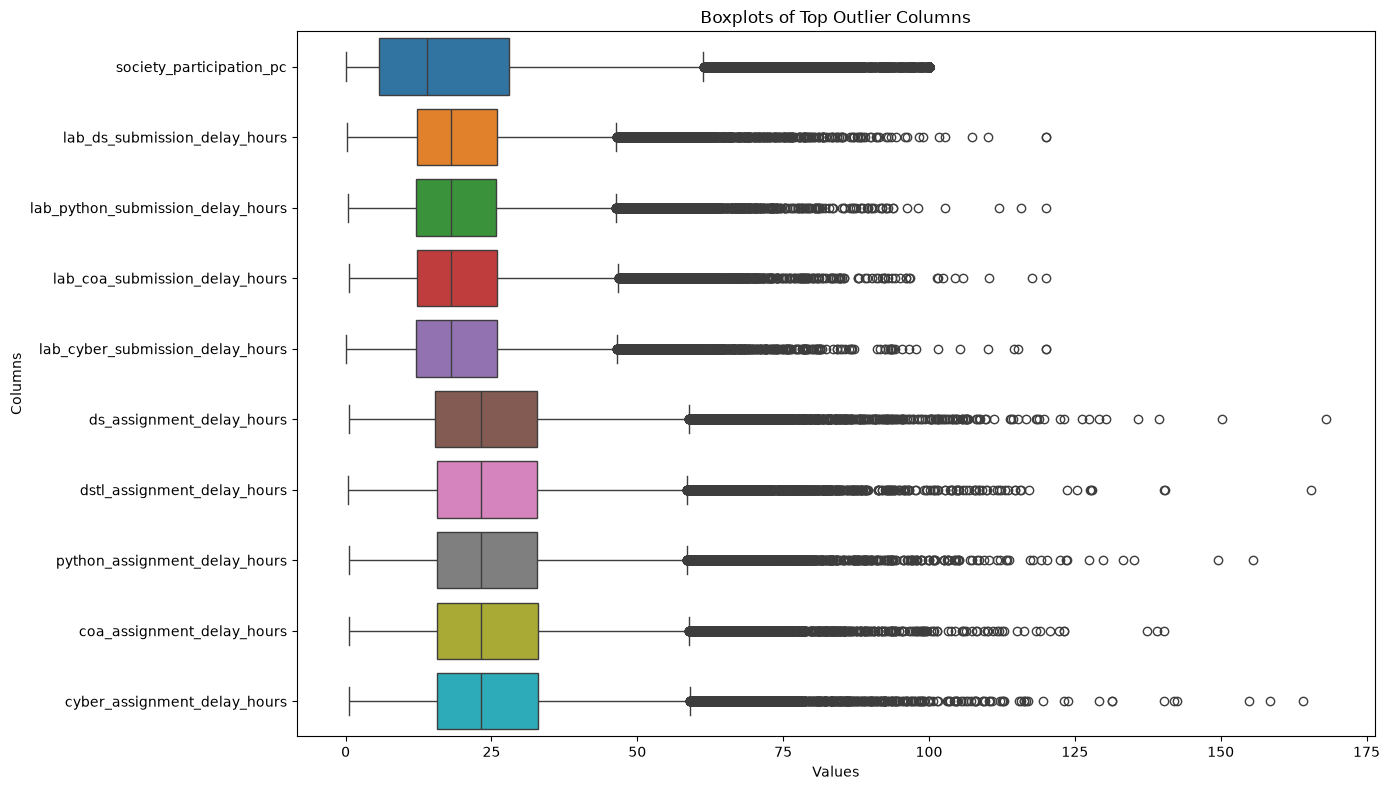

In [35]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df[outlier_cols],orient="h")
plt.title("Boxplots of Top Outlier Columns")
plt.xlabel("Values")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()


# Fill Missing Text


In [36]:
df[text_cols].isnull().sum()


full_name                2294
class_section            2245
sports_activity_level    2248
dtype: int64

In [37]:
df[df["full_name"].isnull()][["roll_no","full_name"]].head(10)


,roll_no,full_name
8,210029012530,NaN
30,210029047594,NaN
37,210029054208,NaN
43,210029023660,NaN
44,210029016013,NaN
49,210029046974,NaN
58,210029047400,NaN
76,210029012059,NaN
118,210029049011,NaN
131,210029030403,NaN


In [38]:
df["full_name"]=df["full_name"].fillna("Unknown")


In [39]:
df["class_section"]=df["class_section"].fillna("UNKNOWN")


In [40]:
df["sports_activity_level"]=df["sports_activity_level"].fillna("unknown")


In [41]:
df[text_cols].isnull().sum()


full_name                0
class_section            0
sports_activity_level    0
dtype: int64

# Fill Missing Numbers


In [42]:
df[attendance_cols].isnull().sum()


overall_attendance_pct       2320
theory_attendance_pct        2343
practical_attendance_pct     2289
coa_attendance_pct           2354
maths4_attendance_pct        2330
dstl_attendance_pct          2235
ds_attendance_pct            2306
python_attendance_pct        2309
cyber_attendance_pct         2258
lab_ds_attendance_pct        2288
lab_python_attendance_pct    2356
lab_coa_attendance_pct       2385
lab_cyber_attendance_pct     2338
dtype: int64

In [43]:
df[attendance_cols]=df[attendance_cols].fillna(0)


In [44]:
df[attendance_cols].isnull().sum().sum()


np.int64(0)

In [45]:
df[attendance_cols].describe()


,overall_attendance_pct,theory_attendance_pct,practical_attendance_pct,coa_attendance_pct,maths4_attendance_pct,dstl_attendance_pct,ds_attendance_pct,python_attendance_pct,cyber_attendance_pct,lab_ds_attendance_pct,lab_python_attendance_pct,lab_coa_attendance_pct,lab_cyber_attendance_pct
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,67.408985,67.256348,69.110157,67.143045,67.157097,67.257484,67.156052,67.186219,67.287138,68.922770,68.860200,68.820295,68.894890
std,23.872563,24.069156,24.228160,24.348708,24.342112,24.137459,24.283733,24.284911,24.200093,24.338326,24.457563,24.513908,24.405114
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.800000,55.300000,57.400000,55.000000,54.800000,55.000000,54.800000,54.800000,55.000000,56.800000,56.900000,56.900000,56.900000
50%,71.300000,71.200000,73.200000,71.200000,71.100000,71.000000,71.100000,71.200000,71.200000,73.000000,73.100000,73.100000,73.100000
75%,84.600000,84.800000,86.900000,85.000000,85.100000,85.100000,85.000000,85.200000,85.100000,87.100000,87.100000,87.000000,87.100000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [46]:
df[basic_cols].isnull().sum()


medical_leave_days          2419
society_participation_pc    2255
dtype: int64

In [47]:
df[basic_cols]=df[basic_cols].fillna(0)


In [48]:
df[basic_cols].isnull().sum().sum()


np.int64(0)

In [49]:
df[basic_cols].describe()


,medical_leave_days,society_participation_pc
count,46500.000000,46500.000000
mean,1.907333,19.049976
std,1.456464,19.470233
min,0.000000,0.000000
25%,1.000000,4.800000
50%,2.000000,13.000000
75%,3.000000,27.000000
max,11.000000,100.000000


In [50]:
df[coa_cols].isnull().sum()


coa_st1_marks                 2334
coa_st2_marks                 2297
coa_put_marks                 2463
coa_unit_1_marks              2297
coa_unit_2_marks              2266
coa_unit_3_marks              2322
coa_unit_4_marks              2308
coa_unit_5_marks              2377
coa_assignment_score          2318
coa_assignment_delay_hours    2344
coa_quiz_score                2309
dtype: int64

In [51]:
df[coa_cols]=df[coa_cols].fillna(0)


In [52]:
df[coa_cols].isnull().sum().sum()


np.int64(0)

In [53]:
df[coa_cols].describe()


,coa_st1_marks,coa_st2_marks,coa_put_marks,coa_unit_1_marks,coa_unit_2_marks,coa_unit_3_marks,coa_unit_4_marks,coa_unit_5_marks,coa_assignment_score,coa_assignment_delay_hours,coa_quiz_score
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,20.238256,20.243015,67.338819,13.500708,13.491938,13.482798,13.486759,13.471118,6.725834,24.414265,6.733402
std,7.115077,7.096671,23.699464,4.758567,4.769004,4.767740,4.774305,4.786441,2.445997,14.895806,2.440741
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.800000,16.800000,56.300000,11.200000,11.100000,11.200000,11.200000,11.200000,5.500000,14.300000,5.500000
50%,21.500000,21.400000,71.600000,14.300000,14.300000,14.300000,14.300000,14.300000,7.100000,22.400000,7.100000
75%,25.300000,25.300000,84.100000,16.900000,16.900000,16.900000,16.900000,16.900000,8.500000,32.200000,8.500000
max,30.000000,30.000000,100.000000,20.000000,20.000000,20.000000,20.000000,20.000000,10.000000,140.300000,10.000000


In [54]:
df[maths4_cols].isnull().sum()


maths4_st1_marks                 2409
maths4_st2_marks                 2343
maths4_put_marks                 2307
maths4_unit_1_marks              2326
maths4_unit_2_marks              2404
maths4_unit_3_marks              2335
maths4_unit_4_marks              2345
maths4_unit_5_marks              2322
maths4_assignment_score          2394
maths4_assignment_delay_hours    2309
maths4_quiz_score                2358
dtype: int64

In [55]:
df[maths4_cols]=df[maths4_cols].fillna(0)


In [56]:
df[maths4_cols].isnull().sum().sum()


np.int64(0)

In [57]:
df[maths4_cols].describe()


,maths4_st1_marks,maths4_st2_marks,maths4_put_marks,maths4_unit_1_marks,maths4_unit_2_marks,maths4_unit_3_marks,maths4_unit_4_marks,maths4_unit_5_marks,maths4_assignment_score,maths4_assignment_delay_hours,maths4_quiz_score
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,20.188852,20.217662,67.633639,13.486742,13.459647,13.492759,13.485340,13.493198,6.712518,24.429998,6.726581
std,7.157677,7.123572,23.431880,4.771488,4.801741,4.780238,4.786316,4.776876,2.460845,14.840980,2.456489
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.800000,16.800000,56.675000,11.200000,11.200000,11.200000,11.200000,11.200000,5.500000,14.400000,5.500000
50%,21.400000,21.400000,71.600000,14.300000,14.300000,14.300000,14.300000,14.300000,7.100000,22.400000,7.100000
75%,25.300000,25.300000,84.300000,16.900000,16.900000,16.900000,16.900000,16.900000,8.500000,32.300000,8.500000
max,30.000000,30.000000,100.000000,20.000000,20.000000,20.000000,20.000000,20.000000,10.000000,151.000000,10.000000


In [58]:
df[dstl_cols].isnull().sum()


dstl_st1_marks                 2335
dstl_st2_marks                 2463
dstl_put_marks                 2267
dstl_unit_1_marks              2425
dstl_unit_2_marks              2343
dstl_unit_3_marks              2378
dstl_unit_4_marks              2329
dstl_unit_5_marks              2301
dstl_assignment_score          2332
dstl_assignment_delay_hours    2383
dstl_quiz_score                2344
dtype: int64

In [59]:
df[dstl_cols]=df[dstl_cols].fillna(0)


In [60]:
df[dstl_cols].isnull().sum().sum()


np.int64(0)

In [61]:
df[dstl_cols].describe()


,dstl_st1_marks,dstl_st2_marks,dstl_put_marks,dstl_unit_1_marks,dstl_unit_2_marks,dstl_unit_3_marks,dstl_unit_4_marks,dstl_unit_5_marks,dstl_assignment_score,dstl_assignment_delay_hours,dstl_quiz_score
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,20.232609,20.184024,67.684398,13.456512,13.480120,13.476854,13.492073,13.504828,6.726069,24.343916,6.726837
std,7.130269,7.190353,23.337719,4.817184,4.783921,4.793690,4.766693,4.765787,2.454989,14.909691,2.452398
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.800000,16.800000,56.500000,11.100000,11.200000,11.200000,11.200000,11.200000,5.500000,14.300000,5.500000
50%,21.400000,21.400000,71.800000,14.300000,14.300000,14.300000,14.300000,14.300000,7.100000,22.400000,7.100000
75%,25.300000,25.300000,84.300000,16.900000,16.900000,16.900000,16.900000,16.900000,8.500000,32.100000,8.500000
max,30.000000,30.000000,100.000000,20.000000,20.000000,20.000000,20.000000,20.000000,10.000000,165.500000,10.000000


In [62]:
df[ds_cols].isnull().sum()


ds_st1_marks                 2300
ds_st2_marks                 2222
ds_put_marks                 2421
ds_unit_1_marks              2358
ds_unit_2_marks              2366
ds_unit_3_marks              2285
ds_unit_4_marks              2322
ds_unit_5_marks              2240
ds_assignment_score          2363
ds_assignment_delay_hours    2375
ds_quiz_score                2345
dtype: int64

In [63]:
df[ds_cols]=df[ds_cols].fillna(0)


In [64]:
df[ds_cols].isnull().sum().sum()


np.int64(0)

In [65]:
df[ds_cols].describe()


,ds_st1_marks,ds_st2_marks,ds_put_marks,ds_unit_1_marks,ds_unit_2_marks,ds_unit_3_marks,ds_unit_4_marks,ds_unit_5_marks,ds_assignment_score,ds_assignment_delay_hours,ds_quiz_score
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,20.248428,20.273185,67.440056,13.494454,13.484708,13.505252,13.497258,13.518092,6.719723,24.378178,6.727738
std,7.102773,7.046383,23.635799,4.793796,4.792005,4.759003,4.775166,4.750692,2.457949,15.077170,2.442230
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.900000,16.900000,56.400000,11.200000,11.200000,11.200000,11.200000,11.200000,5.500000,14.200000,5.500000
50%,21.500000,21.500000,71.600000,14.300000,14.300000,14.300000,14.300000,14.300000,7.100000,22.300000,7.100000
75%,25.300000,25.300000,84.100000,16.900000,16.900000,16.900000,16.900000,16.900000,8.500000,32.200000,8.500000
max,30.000000,30.000000,100.000000,20.000000,20.000000,20.000000,20.000000,20.000000,10.000000,168.000000,10.000000


In [66]:
df[python_cols].isnull().sum()


python_st1_marks                 2358
python_st2_marks                 2423
python_put_marks                 2348
python_unit_1_marks              2269
python_unit_2_marks              2327
python_unit_3_marks              2393
python_unit_4_marks              2329
python_unit_5_marks              2375
python_assignment_score          2335
python_assignment_delay_hours    2226
python_quiz_score                2342
dtype: int64

In [67]:
df[python_cols]=df[python_cols].fillna(0)


In [68]:
df[python_cols].isnull().sum().sum()


np.int64(0)

In [69]:
df[python_cols].describe()


,python_st1_marks,python_st2_marks,python_put_marks,python_unit_1_marks,python_unit_2_marks,python_unit_3_marks,python_unit_4_marks,python_unit_5_marks,python_assignment_score,python_assignment_delay_hours,python_quiz_score
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,20.252013,20.216903,67.587529,13.504953,13.502127,13.474774,13.485482,13.497488,6.727226,24.480206,6.734923
std,7.142888,7.183627,23.515692,4.765609,4.780401,4.807577,4.788454,4.797761,2.455940,14.885988,2.451324
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.900000,16.800000,56.600000,11.200000,11.200000,11.200000,11.200000,11.200000,5.500000,14.400000,5.500000
50%,21.500000,21.500000,71.700000,14.300000,14.300000,14.300000,14.300000,14.300000,7.100000,22.500000,7.100000
75%,25.300000,25.300000,84.200000,16.900000,16.900000,16.900000,16.900000,16.900000,8.500000,32.200000,8.500000
max,30.000000,30.000000,100.000000,20.000000,20.000000,20.000000,20.000000,20.000000,10.000000,155.500000,10.000000


In [70]:
df[cyber_cols].isnull().sum()


cyber_st1_marks                 2326
cyber_st2_marks                 2237
cyber_put_marks                 2389
cyber_unit_1_marks              2265
cyber_unit_2_marks              2311
cyber_unit_3_marks              2335
cyber_unit_4_marks              2323
cyber_unit_5_marks              2217
cyber_assignment_score          2209
cyber_assignment_delay_hours    2227
cyber_quiz_score                2305
dtype: int64

In [71]:
df[cyber_cols]=df[cyber_cols].fillna(0)


In [72]:
df[cyber_cols].isnull().sum().sum()


np.int64(0)

In [73]:
df[cyber_cols].describe()


,cyber_st1_marks,cyber_st2_marks,cyber_put_marks,cyber_unit_1_marks,cyber_unit_2_marks,cyber_unit_3_marks,cyber_unit_4_marks,cyber_unit_5_marks,cyber_assignment_score,cyber_assignment_delay_hours,cyber_quiz_score
count,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000
mean,20.272437,20.294832,67.474456,13.507127,13.497525,13.484770,13.495131,13.525159,6.757566,24.545178,6.730163
std,7.129819,7.064656,23.561768,4.750852,4.781773,4.785819,4.775991,4.739861,2.423115,15.013632,2.447479
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.800000,16.900000,56.400000,11.200000,11.200000,11.200000,11.200000,11.200000,5.500000,14.400000,5.500000
50%,21.500000,21.500000,71.700000,14.300000,14.300000,14.300000,14.300000,14.300000,7.200000,22.500000,7.100000
75%,25.400000,25.300000,84.100000,16.900000,16.900000,16.900000,16.900000,16.900000,8.500000,32.400000,8.500000
max,30.000000,30.000000,100.000000,20.000000,20.000000,20.000000,20.000000,20.000000,10.000000,164.100000,10.000000


In [74]:
df[lab_ds_cols].isnull().sum()


lab_ds_execution_score           2353
lab_ds_viva_score                2341
lab_ds_submission_delay_hours    2369
dtype: int64

In [75]:
df[lab_ds_cols]=df[lab_ds_cols].fillna(0)


In [76]:
df[lab_ds_cols].isnull().sum().sum()


np.int64(0)

In [77]:
df[lab_ds_cols].describe()


,lab_ds_execution_score,lab_ds_viva_score,lab_ds_submission_delay_hours
count,46500.000000,46500.000000,46500.000000
mean,33.676942,20.211989,19.247837
std,12.063518,7.266314,12.079173
min,0.000000,0.000000,0.000000
25%,27.900000,16.600000,11.100000
50%,35.700000,21.400000,17.500000
75%,42.400000,25.500000,25.300000
max,50.000000,30.000000,120.000000


In [78]:
df[lab_python_cols].isnull().sum()


lab_python_execution_score           2310
lab_python_viva_score                2326
lab_python_submission_delay_hours    2292
dtype: int64

In [79]:
df[lab_python_cols]=df[lab_python_cols].fillna(0)


In [80]:
df[lab_python_cols].isnull().sum().sum()


np.int64(0)

In [81]:
df[lab_python_cols].describe()


,lab_python_execution_score,lab_python_viva_score,lab_python_submission_delay_hours
count,46500.000000,46500.000000,46500.000000
mean,33.755987,20.225133,19.255116
std,12.022471,7.250458,11.997860
min,0.000000,0.000000,0.000000
25%,27.900000,16.675000,11.200000
50%,35.800000,21.400000,17.500000
75%,42.400000,25.500000,25.300000
max,50.000000,30.000000,120.000000


In [82]:
df[lab_coa_cols].isnull().sum()


lab_coa_execution_score           2251
lab_coa_viva_score                2321
lab_coa_submission_delay_hours    2455
dtype: int64

In [83]:
df[lab_coa_cols]=df[lab_coa_cols].fillna(0)


In [84]:
df[lab_coa_cols].isnull().sum().sum()


np.int64(0)

In [85]:
df[lab_coa_cols].describe()


,lab_coa_execution_score,lab_coa_viva_score,lab_coa_submission_delay_hours
count,46500.000000,46500.000000,46500.000000
mean,33.744497,20.219540,19.253843
std,11.937979,7.249102,12.127842
min,0.000000,0.000000,0.000000
25%,27.900000,16.700000,11.100000
50%,35.700000,21.400000,17.400000
75%,42.300000,25.500000,25.400000
max,50.000000,30.000000,120.000000


In [86]:
df[lab_cyber_cols].isnull().sum()


lab_cyber_execution_score           2342
lab_cyber_viva_score                2343
lab_cyber_submission_delay_hours    2310
dtype: int64

In [87]:
df[lab_cyber_cols]=df[lab_cyber_cols].fillna(0)


In [88]:
df[lab_cyber_cols].isnull().sum().sum()


np.int64(0)

In [89]:
df[lab_cyber_cols].describe()


,lab_cyber_execution_score,lab_cyber_viva_score,lab_cyber_submission_delay_hours
count,46500.000000,46500.000000,46500.000000
mean,33.673424,20.161318,19.235243
std,12.037686,7.255260,12.019704
min,0.000000,0.000000,0.000000
25%,27.700000,16.600000,11.100000
50%,35.700000,21.400000,17.500000
75%,42.400000,25.400000,25.300000
max,50.000000,30.000000,120.000000


# Fix Final Grade


In [90]:
df["final_semester_grade"].isnull().sum()


np.int64(2192)

In [91]:
df["grade_was_missing"]=df["final_semester_grade"].isnull().astype(int)


In [92]:
df["grade_was_missing"].sum()


np.int64(2192)

In [93]:
df["final_semester_grade"]=df["final_semester_grade"].fillna(0)


In [94]:
df["final_semester_grade"].isnull().sum()


np.int64(0)

# Final Check


In [95]:
df.isnull().sum().sum()


np.int64(2434)

In [96]:
df.isnull().sum()[df.isnull().sum()>0]


previous_cgpa    2434
dtype: int64

In [97]:
df.shape


(46500, 102)

In [98]:
print("99 original columns :",all(c in df.columns for c in all_groups))


99 original columns : True


In [99]:
out_of_range=0
for col in col_rules:
    low=col_rules[col][0]
    high=col_rules[col][1]
    if high is None:
        out_of_range=out_of_range+int((df[col]<low).sum())
    else:
        out_of_range=out_of_range+int(((df[col]<low)|(df[col]>high)).sum())
print("Out of Range Values :",out_of_range)


Out of Range Values : 0


In [100]:
df.duplicated().sum()


np.int64(0)

In [101]:
df.dtypes.value_counts()


float64    95
int64       4
str         3
Name: count, dtype: int64

In [102]:
print(sorted(df["class_section"].unique()))
print(sorted(df["sports_activity_level"].unique()))


['CS-AI', 'CS-DS', 'CSE-A', 'CSE-B', 'CSE-C', 'IT-A', 'IT-B', 'UNKNOWN']
['Not in sports', 'high', 'low', 'moderate', 'none', 'unknown']


In [103]:
df.describe()


,roll_no,overall_attendance_pct,theory_attendance_pct,practical_attendance_pct,previous_cgpa,medical_leave_days,society_participation_pc,final_semester_grade,coa_attendance_pct,maths4_attendance_pct,...,lab_python_submission_delay_hours,lab_coa_execution_score,lab_coa_viva_score,lab_coa_submission_delay_hours,lab_cyber_execution_score,lab_cyber_viva_score,lab_cyber_submission_delay_hours,outlier_count,is_outlier_student,grade_was_missing
count,4.650000e+04,46500.000000,46500.000000,46500.000000,44066.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,...,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.000000,46500.00000
mean,2.100290e+11,67.408985,67.256348,69.110157,7.987138,1.907333,19.049976,7.478174,67.143045,67.157097,...,19.255116,33.744497,20.219540,19.253843,33.673424,20.161318,19.235243,0.778043,0.030430,0.04714
std,1.342354e+04,23.872563,24.069156,24.228160,1.207611,1.456464,19.470233,2.064622,24.348708,24.342112,...,11.997860,11.937979,7.249102,12.127842,12.037686,7.255260,12.019704,3.033985,0.171769,0.21194
min,2.100290e+11,0.000000,0.000000,0.000000,2.860000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.100290e+11,55.800000,55.300000,57.400000,7.200000,1.000000,4.800000,6.850000,55.000000,54.800000,...,11.200000,27.900000,16.700000,11.100000,27.700000,16.600000,11.100000,0.000000,0.000000,0.00000
50%,2.100290e+11,71.300000,71.200000,73.200000,8.110000,2.000000,13.000000,7.910000,71.200000,71.100000,...,17.500000,35.700000,21.400000,17.400000,35.700000,21.400000,17.500000,0.000000,0.000000,0.00000
75%,2.100290e+11,84.600000,84.800000,86.900000,8.910000,3.000000,27.000000,8.760000,85.000000,85.100000,...,25.300000,42.300000,25.500000,25.400000,42.400000,25.400000,25.300000,1.000000,0.000000,0.00000
max,2.100291e+11,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,10.000000,100.000000,100.000000,...,120.000000,50.000000,30.000000,120.000000,50.000000,30.000000,120.000000,66.000000,1.000000,1.00000


In [104]:
df["class_section"].value_counts()


class_section
IT-A       9874
CSE-A      9784
CSE-B      4944
CS-DS      4942
CS-AI      4919
CSE-C      4901
IT-B       4891
UNKNOWN    2245
Name: count, dtype: int64

In [105]:
df["sports_activity_level"].value_counts()


sports_activity_level
moderate         11090
low              11078
high             11069
Not in sports     5553
none              5462
unknown           2248
Name: count, dtype: int64

## Save cleaned dataset for downstream notebooks


In [106]:
CLEANED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CLEANED_DATA_PATH, index=False)
print(f"Saved cleaned dataset to {CLEANED_DATA_PATH}")


Saved cleaned dataset to /workspaces/edu-growth/data/processed/edu_growth_cleaned.csv
